## Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Model Saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("Data Warehouse Multiclass.csv")

df.head()

,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


## Dataset Information

In [3]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (280985, 39)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280985 entries, 0 to 280984
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   composite_key         280985 non-null  object 
 1   age_level             280985 non-null  object 
 2   gender                280985 non-null  object 
 3   bmi_level             280985 non-null  object 
 4   smoking               280985 non-null  object 
 5   diabetes              280985 non-null  object 
 6   age                   280985 non-null  int64  
 7   age_normalized        280985 non-null  float64
 8   bmi                   280985 non-null  float64
 9   hypertension          280985 non-null  float64
 10  heart_disease         280985 non-null  float64
 11  HbA1c_level           280985 non-null  float64
 12  glucose               280985 non-null  float64
 13  cholesterol           280985 non-null  float64
 14  sleep_hours           28

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,280985.0,49.665865,21.682350,2.000000,32.000000,50.000000,67.000000,89.000000
age_normalized,280985.0,0.547883,0.249222,0.000000,0.344827,0.551724,0.747126,1.000000
bmi,280985.0,27.490663,7.040373,10.010000,22.100000,27.320000,32.700000,95.690000
hypertension,280985.0,0.128218,0.187346,0.000000,0.000000,0.071429,0.217063,1.000000
heart_disease,280985.0,0.073390,0.138243,0.000000,0.000000,0.007299,0.115053,1.000000
HbA1c_level,280985.0,5.947475,0.954072,3.500000,5.384805,5.800000,6.865766,9.000000
glucose,280985.0,135.258646,38.477865,70.000000,100.000000,138.000000,160.000000,300.000000
cholesterol,280985.0,224.045525,35.525530,150.000000,202.000000,225.000000,243.000000,300.000000
sleep_hours,280985.0,6.954652,1.426412,4.000000,6.200000,6.975185,7.700000,10.000000
triglycerides,280985.0,178.995744,67.336085,50.000000,129.000000,179.000000,242.000000,400.000000


## Missing Value Analysis

In [5]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

## Exploratory Data Analysis

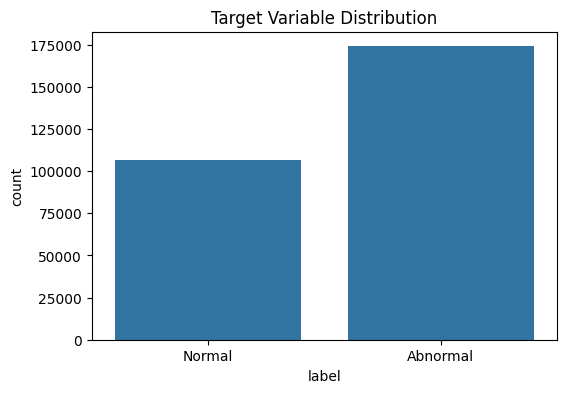

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)

plt.title("Target Variable Distribution")
plt.show()

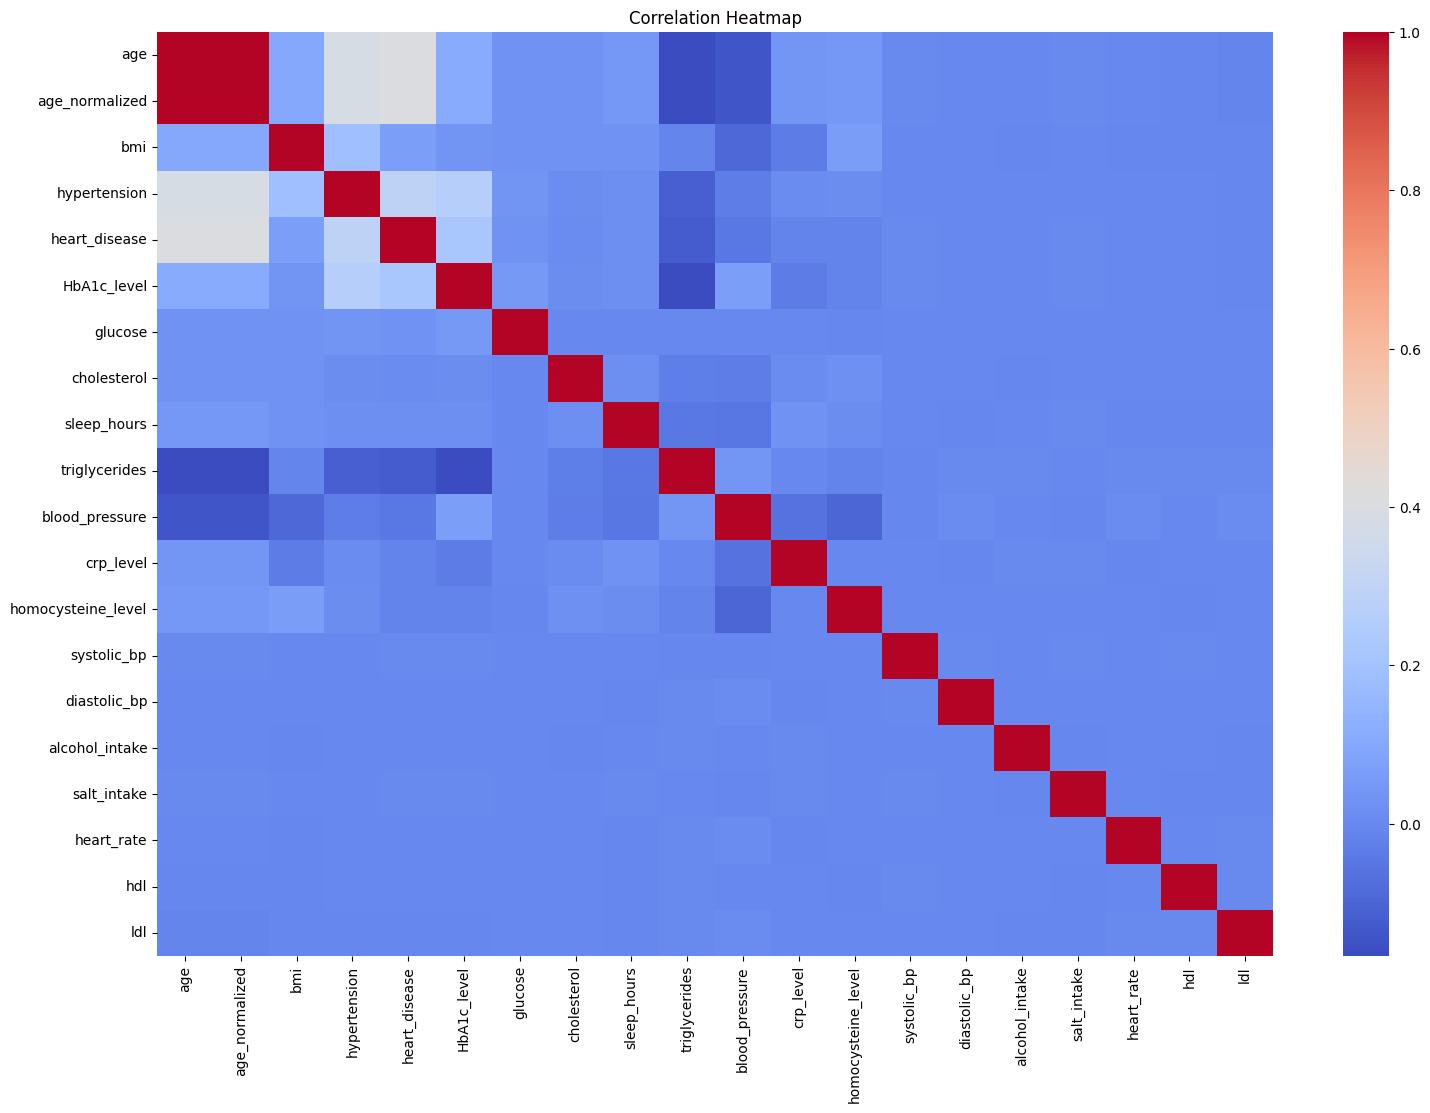

In [7]:
# Numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Correlation heatmap
plt.figure(figsize=(18,12))

sns.heatmap(
    df[numerical_cols].corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

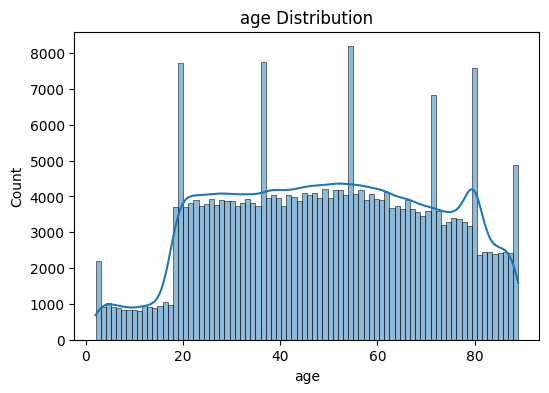

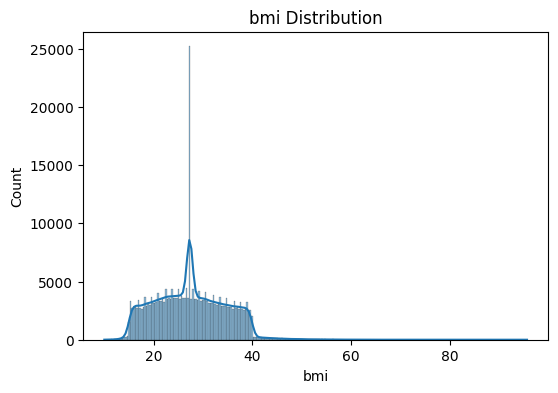

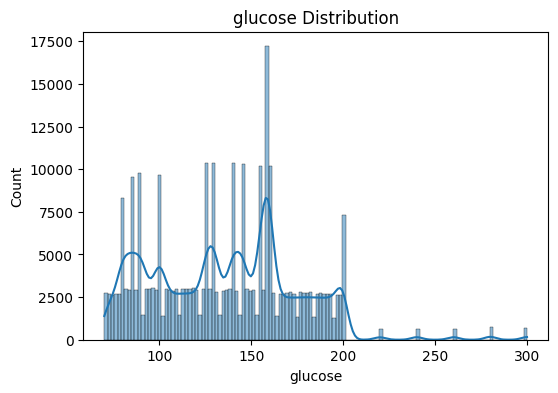

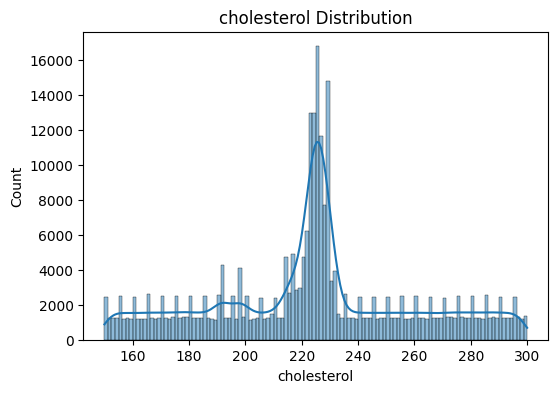

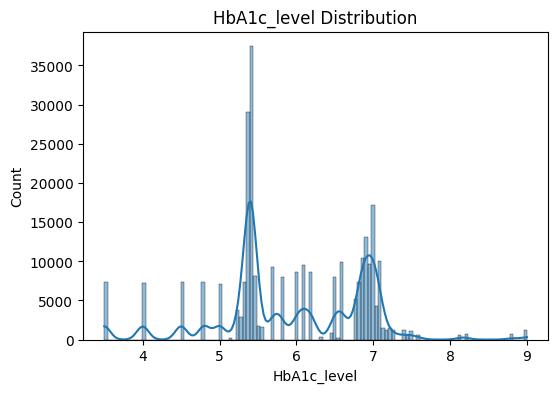

In [8]:
# Distribution plots
important_features = [
    'age',
    'bmi',
    'glucose',
    'cholesterol',
    'HbA1c_level'
]

for feature in important_features:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[feature], kde=True)
    
    plt.title(f"{feature} Distribution")
    
    plt.show()

## Data Preprocessing

In [9]:
# Remove unnecessary columns

drop_columns = [
    'composite_key',
    'source_dataset',
    'disease_flags',
    'sublabel'
]

df.drop(columns=drop_columns, inplace=True, errors='ignore')

# Separate categorical and numerical columns

In [10]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

categorical_cols.remove('label')

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'high_blood_pressure', 'sugar_consumption', 'education_level', 'employment_status']

Numerical Columns:
['age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']


## Handle missing values

In [11]:
num_imputer = SimpleImputer(strategy='median')

cat_imputer = SimpleImputer(strategy='most_frequent')

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [12]:
# Encode categorical variables

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

## Feature Engineering

In [13]:
# Create additional healthcare risk feature

df['health_risk_score'] = (
    df['glucose'] +
    df['cholesterol'] +
    df['HbA1c_level'] +
    df['bmi']
)

# Encode target column

In [14]:
target_encoder = LabelEncoder()

df['label'] = target_encoder.fit_transform(df['label'])

# Split features and target

In [15]:
X = df.drop('label', axis=1)

y = df['label']

# Feature scaling

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Train-test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Model Training

In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# Train and evaluate models

In [19]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred, average='weighted')
    
    recall = recall_score(y_test, y_pred, average='weighted')
    
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.856825,0.858559,0.856825,0.857416
1,Decision Tree,0.868694,0.869174,0.868694,0.868898
2,Random Forest,0.910049,0.920348,0.910049,0.907214
3,Gradient Boosting,0.908269,0.918263,0.908269,0.905400
4,XGBoost,0.908323,0.917345,0.908323,0.905599


## Hyperparameter Tuning

### Hyperparameter tuning for Random Forest

In [20]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'n_estimators': 200}


## Model Evaluation

### Predictions

In [21]:
y_pred = best_model.predict(X_test)

### Classification report

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     34820
           1       0.99      0.77      0.87     21377

    accuracy                           0.91     56197
   macro avg       0.93      0.88      0.90     56197
weighted avg       0.92      0.91      0.91     56197



### Confusion matrix

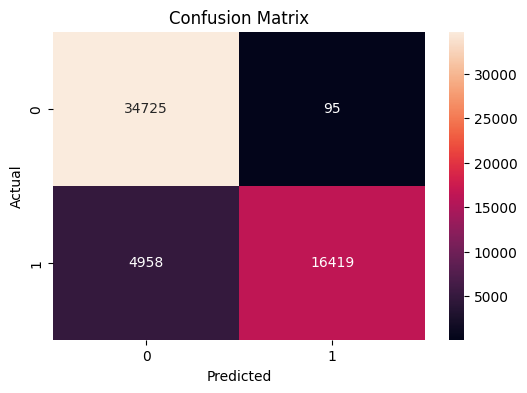

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Feature Importance

In [24]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
8,hypertension,0.180007
4,diabetes,0.130709
9,heart_disease,0.097662
10,HbA1c_level,0.079419
14,triglycerides,0.059724
13,sleep_hours,0.039895
25,systolic_bp,0.039613
30,hdl,0.037620
31,ldl,0.034228
12,cholesterol,0.032409


## Plot feature importance

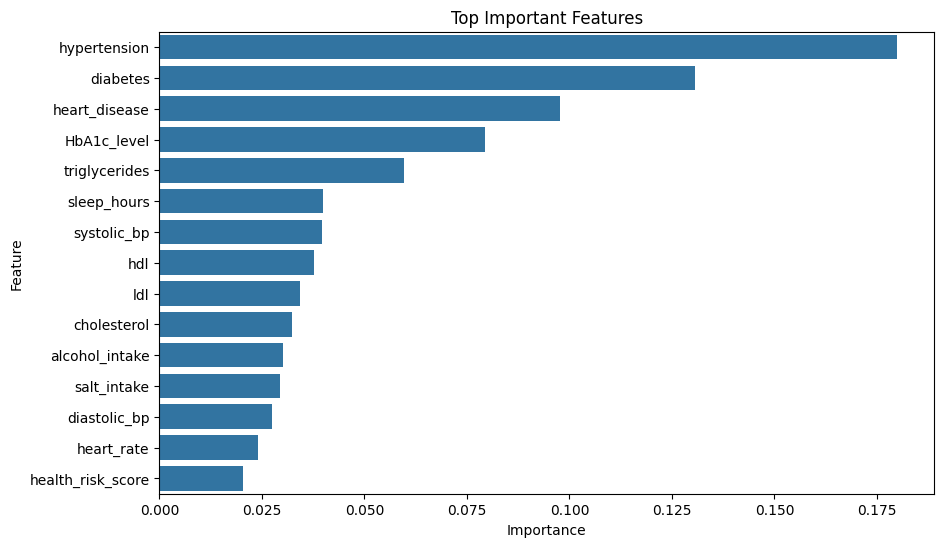

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)

plt.title("Top Important Features")

plt.show()

## Save Model

In [26]:
# Save trained model

joblib.dump(best_model, "best_healthcare_model.pkl")

print("Model saved successfully.")

Model saved successfully.
